# Chapter 6: Scaling & Transformations

In [47]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib as mpl
import matplotlib.pyplot as plt

## 6.1: Introduction

During this exercise you will make your own scaling function(s). We will aply this to the hepathlon dataset of the Tokyo 2020 olympics which Nafi Thiam obviously won.
 
You will explore the different scaling and normalization methods by visualising subsets of the data, after which you will make one big visualization to make some conclusons!

## 6.2: Data cleaning

There are a few issues with missing values in the data. Find the problems and fix them before we start. You can leave the missing values as NaN's for now.

*Hint: You don't have to manually fix these, you can use the pandas.read_csv function to fix everything the moment you read the file with the na_values option. Look online to see how this works or just try it.*

In [48]:
Tokyo2020 = pd.read_csv("Tokyo_2020_hepathlon.txt", sep = ";",na_values=["DNF","DNS","DQ"])
Tokyo2020

,Rank,Country,Name,Final_Points,100m_hurdles_Result,100m_hurdles_Points,200m_Result,200m_Points,800m_Result,800m_Points,High_jump_Result,High_jump_Points,Javelin_Result,Javelin_Points,Long_jump_Result,Long_jump_Points,Shot_put_Result,Shot_put_Points
0,1.0,BEL,THIAM Nafissatou,6791.0,13.54,1044,24.90,896,2:15.98,879,1.92,1132,54.68,951,6.60,1040,14.82,849
1,2.0,NED,VETTER Anouk,6689.0,13.09,1111,23.81,999,2:18.72,841,1.80,978,51.20,883,6.47,997,15.29,880
2,3.0,NED,OOSTERWEGEL Emma,6590.0,13.36,1071,24.25,957,2:11.09,949,1.80,978,54.60,949,6.29,940,13.28,746
3,4.0,BEL,VIDTS Noor,6571.0,13.17,1099,23.70,1010,2:09.05,979,1.83,1016,41.80,702,6.32,949,14.33,816
4,5.0,USA,WILLIAMS Kendell,6508.0,12.97,1129,24.00,981,2:16.91,866,1.80,978,48.78,836,6.57,1030,12.41,688
5,6.0,USA,KUNZ Annie,6420.0,13.49,1052,24.12,969,2:15.93,880,1.80,978,42.77,721,6.32,949,15.15,871
6,7.0,GER,SCHAFER Carolin,6419.0,13.29,1081,24.33(.325),949,2:14.82,895,1.80,978,54.10,940,5.78,783,13.99,793
7,8.0,AUT,DADIC Ivona,6403.0,13.61,1034,24.33(.321),949,2:15.10,891,1.83,1016,48.40,829,6.11,883,14.10,801
8,9.0,USA,BOUGARD Erica,6379.0,13.14,1103,24.08,973,2:15.92,880,1.86,1054,46.60,794,6.06,868,12.69,707
9,10.0,CHN,ZHENG Ninali,6318.0,13.27,1084,24.56,928,2:10.35,960,1.80,978,42.60,717,6.12,887,13.55,764


In [49]:
Tokyo2020.dropna(subset=["Javelin_Result"])

,Rank,Country,Name,Final_Points,100m_hurdles_Result,100m_hurdles_Points,200m_Result,200m_Points,800m_Result,800m_Points,High_jump_Result,High_jump_Points,Javelin_Result,Javelin_Points,Long_jump_Result,Long_jump_Points,Shot_put_Result,Shot_put_Points
0,1.0,BEL,THIAM Nafissatou,6791.0,13.54,1044,24.90,896,2:15.98,879,1.92,1132,54.68,951,6.60,1040,14.82,849
1,2.0,NED,VETTER Anouk,6689.0,13.09,1111,23.81,999,2:18.72,841,1.80,978,51.20,883,6.47,997,15.29,880
2,3.0,NED,OOSTERWEGEL Emma,6590.0,13.36,1071,24.25,957,2:11.09,949,1.80,978,54.60,949,6.29,940,13.28,746
3,4.0,BEL,VIDTS Noor,6571.0,13.17,1099,23.70,1010,2:09.05,979,1.83,1016,41.80,702,6.32,949,14.33,816
4,5.0,USA,WILLIAMS Kendell,6508.0,12.97,1129,24.00,981,2:16.91,866,1.80,978,48.78,836,6.57,1030,12.41,688
5,6.0,USA,KUNZ Annie,6420.0,13.49,1052,24.12,969,2:15.93,880,1.80,978,42.77,721,6.32,949,15.15,871
6,7.0,GER,SCHAFER Carolin,6419.0,13.29,1081,24.33(.325),949,2:14.82,895,1.80,978,54.10,940,5.78,783,13.99,793
7,8.0,AUT,DADIC Ivona,6403.0,13.61,1034,24.33(.321),949,2:15.10,891,1.83,1016,48.40,829,6.11,883,14.10,801
8,9.0,USA,BOUGARD Erica,6379.0,13.14,1103,24.08,973,2:15.92,880,1.86,1054,46.60,794,6.06,868,12.69,707
9,10.0,CHN,ZHENG Ninali,6318.0,13.27,1084,24.56,928,2:10.35,960,1.80,978,42.60,717,6.12,887,13.55,764


## 6.3 Data centering

Create a function which can receive data as input, and which returns the centered data. If you do not remember what centering is, look at the slides of the corresponding lesson.

1. Create a function to center data. Make sure to first clean out any missing values!
2. Center the Javelin Result. 
3. Visualise the centered Javelin results. Make a plot with two subplots: one showing the original histogram and one showing the centered histogram.

In [50]:
Tokyo2020_1=Tokyo2020.dropna(subset=["Javelin_Result"])
def enhancedata(data):
    data_mean = data.mean()
    data_center = data-data_mean
    return data_center
enhancedata(Tokyo2020_1["Javelin_Result"])

0     8.4095
1     4.9295
2     8.3295
3    -4.4705
4     2.5095
5    -3.5005
6     7.8295
7     2.1295
8     0.3295
9    -3.6705
10   -1.3205
11    3.6095
12    4.3195
13   -1.4205
14   -2.3105
15   -9.4305
16   -3.3605
17   -9.2305
18   -1.5205
19   -2.1605
Name: Javelin_Result, dtype: float64

Text(0.5, 1.0, 'Centered Javelin result')

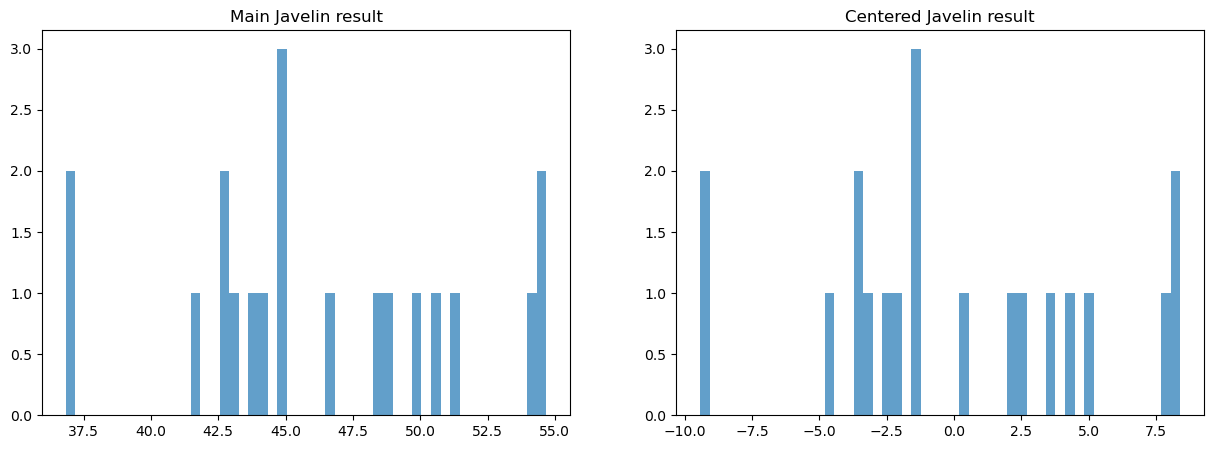

In [51]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].hist(Tokyo2020_1["Javelin_Result"],bins=50,alpha=0.7)
axes[0].set_title("Main Javelin result")

axes[1].hist(enhancedata(Tokyo2020_1["Javelin_Result"]),bins=50,alpha=0.7)
axes[1].set_title("Centered Javelin result")

## 6.4: Standardization (z score)


1. Create a function or update your function to calculate z-scores (i.e. to standardize data). Remember the missing values!
2. standardize the Long Jump results 
3. Visualise the standardized Long Jump Results. Once again create two subplots to show the difference between the original data and the standardized data.

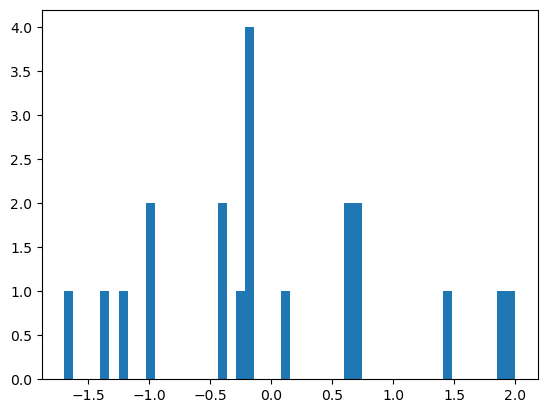

In [52]:
def enhanceNEWdata(data,tech=""):
    data_log = data.apply(np.log10)
    data_log_mean = data_log.mean()
    data_normalized = data_log-data_log_mean

    if(tech=="Zscore"):
        data_to_scale = data.values.reshape((-1,1))
        scaler = preprocessing.StandardScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized=scaler.transform(data_to_scale)
        return data_normalized
    elif(tech=="MinMax"):
        data_to_scale = data.values.reshape((-1,1))
        scaler = preprocessing.MinMaxScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized=scaler.transform(data_to_scale)
        return data_normalized

plt.hist(enhanceNEWdata(Tokyo2020_1["Long_jump_Result"],"Zscore"),bins=50)
plt.show()

## 6.5: Min-Max Normalization



1. Implement Min-Max normalisation in a new or in your exsiting function. Remeber the missing values!
2. min-max normalize the Shot Put Results
3. Visualise the normalised Shot Put Results. Again, make use of two subplots.

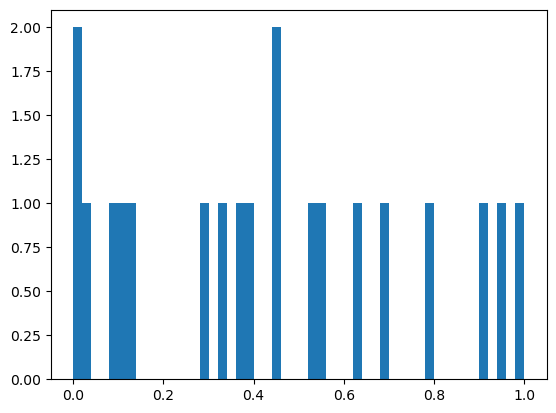

In [53]:
plt.hist(enhanceNEWdata(Tokyo2020_1["Shot_put_Result"],"MinMax"),bins=50)
plt.show()